In [20]:
import numpy as np 
import pandas as pd
import pickle 
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Plot source correlations by layer for models of interest

### First, look standard models

Pilot models used different training set parameters (e.g. number of distractor sources, inclusion of noise).    
These should be treated as differnt models

In [53]:
corr_paths = list(Path('./').glob('*corrs*.pkl'))
corr_paths

[PosixPath('attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4_corrs.pkl'),
 PosixPath('attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4_corrs_w_noise.pkl'),
 PosixPath('attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs.pkl'),
 PosixPath('attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs_at_0dB.pkl'),
 PosixPath('attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4_corrs.pkl'),
 PosixPath('attn_cue_match_target_speech_and_noise_coch_attn_only_corrs_at_0dB.pkl'),
 PosixPath('attn_cue_match_target_speech_and_noise_fc_attn_only_corrs_at_0dB.pkl'),
 PosixPath('attn_cue_match_target_speech_distractor_only_corrs_at_0dB.pkl')]

In [69]:
corr_paths = list(Path('./').glob('*corrs*.pkl'))

corr_paths = [p for p in corr_paths if 'only' not in str(p) and 'noise' not in str(p) and 'pilot' not in str(p)]
corr_paths

[PosixPath('attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4_corrs.pkl'),
 PosixPath('attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs.pkl'),
 PosixPath('attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs_at_0dB.pkl')]

In [70]:

model_dfs = []

# model_names = lambda name: "coch only" if "coch" in name else "fc only" if "fc" in name else "standard"

for path in corr_paths:
    with open(path, 'rb') as f:
        acts = pickle.load(f)
    for layer in acts['fg_corr_results'].keys():
        df = pd.DataFrame.from_dict({'fg_corrs':acts['fg_corr_results'][layer],
                                 'bg_corrs':acts['bg_corr_results'][layer],
                                 'layer': [layer] * len(acts['fg_corr_results'][layer])})
    #                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
        df['model'] = path.stem # model_names(path.stem)
        model_dfs.append(df)

model_df = pd.concat(model_dfs)

In [71]:
results = pd.melt(model_df, id_vars =['layer', 'model'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

results = (results.groupby(["layer", 'Stream', 'model'])["Pearson's r"]
                     .agg(["mean"])
                     .reset_index())
results = results.rename(columns={'mean':"Pearson's r"})

results['Stream'].replace('fg_corrs','corr(target, mixture)',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture)',inplace=True)

layer_order = sorted(results.layer.unique())


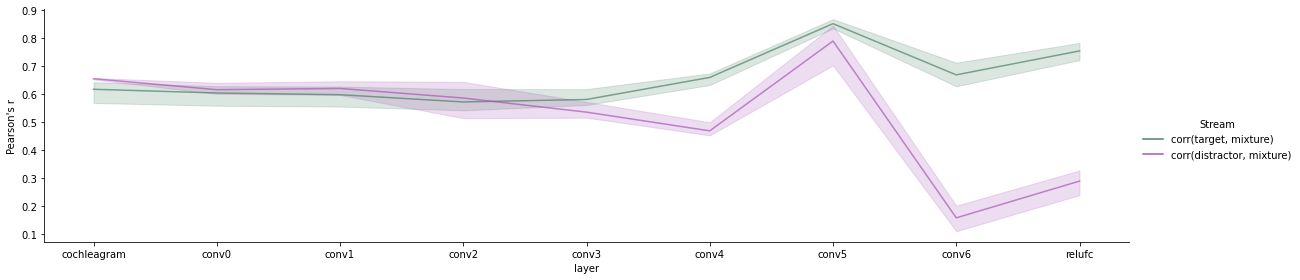

In [73]:

palette = sns.diverging_palette(145, 300,n=2, s=60, as_cmap=False)


g = sns.relplot(data=results, x="layer", y="Pearson's r", hue="Stream", hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
                palette=palette,
                 #style='model',# style_order = ['standard', 'fc only', 'coch only'],
                kind="line", alpha=0.7, height=4, aspect=4, facet_kws=dict(sharex=False, sharey=False),)
# g.map(plt.axhline, y=0.5, color=".7", dashes=(2, 1), zorder=0)
# g.set_titles(row_template="{row_name} architecture",)

#### The pilot model can be excluded - this was trained with only one distractor voice at a time 

## Compare alternate models

Take the top "standard" model and compare to alternate attention implementations 

In [60]:
corr_paths = list(Path('./').glob('*corrs*.pkl'))
wanted_tags = ['attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4_corrs.pkl', 'fc_attn', 'coch_attn']

corr_paths = [p for p in corr_paths if any([tag in str(p) for tag in wanted_tags])]

In [67]:

model_dfs = []

# model_names = lambda name: "coch only" if "coch" in name else "fc only" if "fc" in name else "standard"

for path in corr_paths:
    with open(path, 'rb') as f:
        acts = pickle.load(f)
    for layer in acts['fg_corr_results'].keys():
        df = pd.DataFrame.from_dict({'fg_corrs':acts['fg_corr_results'][layer],
                                 'bg_corrs':acts['bg_corr_results'][layer],
                                 'layer': [layer] * len(acts['fg_corr_results'][layer])})
    #                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
        df['model'] = model_names(path.stem)
        model_dfs.append(df)

model_df = pd.concat(model_dfs)


results = pd.melt(model_df, id_vars =['layer', 'model'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

results = (results.groupby(["layer", 'Stream', 'model'])["Pearson's r"]
                     .agg(["mean"])
                     .reset_index())
results = results.rename(columns={'mean':"Pearson's r"})

results['Stream'].replace('fg_corrs','corr(target, mixture)',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture)',inplace=True)

layer_order = sorted(results.layer.unique())


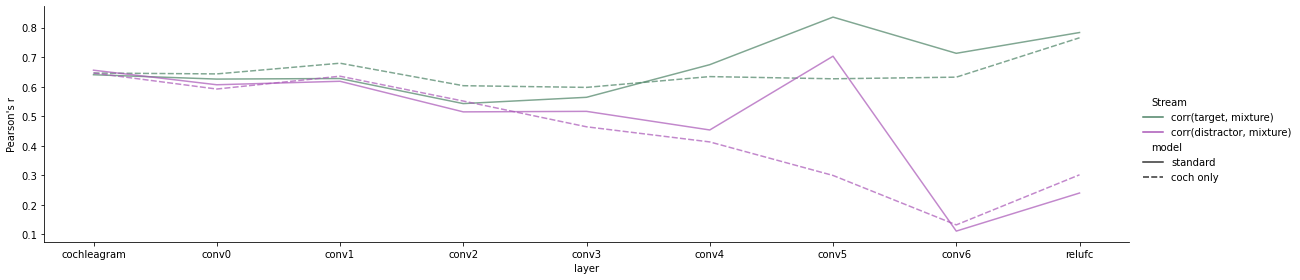

In [ ]:

palette = sns.diverging_palette(145, 300,n=2, s=60, as_cmap=False)


g = sns.relplot(data=results, x="layer", y="Pearson's r", hue="Stream", hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
                palette=palette,
                 style='model', style_order = ['standard', 'coch only', 'fc only'],
                kind="line", alpha=0.7, height=4, aspect=4, facet_kws=dict(sharex=False, sharey=False),)
# g.map(plt.axhline, y=0.5, color=".7", dashes=(2, 1), zorder=0)
# g.set_titles(row_template="{row_name} architecture",)